<a href="https://colab.research.google.com/github/MKumaraShiva/MKumaraShiva/blob/main/amlt1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.85MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.11MB/s]


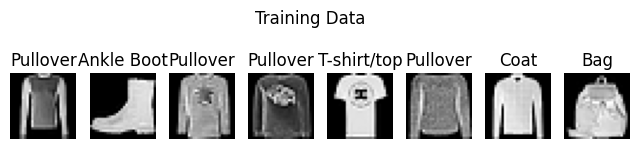

Epoch 1/5, Loss: 0.4015
Epoch 2/5, Loss: 0.2595
Epoch 3/5, Loss: 0.2129


KeyboardInterrupt: 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1️⃣ Load & Preprocess Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                             download=True, transform=transform)
testset = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                            download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

# 2️⃣ Visualize Dataset
def show_images(dataset, title):
    images, labels = next(iter(DataLoader(dataset, batch_size=8, shuffle=True)))
    plt.figure(figsize=(8,2))
    for i in range(8):
        plt.subplot(1, 8, i+1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title(classes[labels[i]])
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_images(trainset, "Training Data")

# 3️⃣ CNN Model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

model = CNN().to(device)

# 4️⃣ Training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/5, Loss: {running_loss/len(trainloader):.4f}")

print("Training Complete")

# 5️⃣ Evaluation
correct, total = 0, 0

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy: {100 * correct / total:.2f}%')

# 6️⃣ Predictions Visualization
def classify_images():
    images, labels = next(iter(testloader))
    images = images.to(device)

    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    plt.figure(figsize=(8,2))
    for i in range(8):
        plt.subplot(1, 8, i+1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.title(classes[predicted[i]])
        plt.axis('off')

    plt.suptitle("Predicted Classes")
    plt.show()

classify_images()